In [2]:
import pandas as pd
dta = pd.read_csv('../data/complaints.csv')
dta.shape


(11522175, 18)

In [3]:
#lowercase column names and replace spaces with underscores
dta.columns = dta.columns.str.lower().str.replace(' ', '_')
dta.head(2)

,date_received,product,sub-product,issue,sub-issue,consumer_complaint_narrative,company_public_response,company,state,zip_code,tags,consumer_consent_provided?,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response?,consumer_disputed?,complaint_id
0,2020-07-06,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,346XX,NaN,Other,Web,2020-07-06,Closed with explanation,Yes,NaN,3730948
1,2025-10-14,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information is missing that should be on the r...,NaN,NaN,"EQUIFAX, INC.",TX,75062,NaN,NaN,Web,2025-10-14,In progress,Yes,NaN,16558024


In [4]:
dta.head(2)
#convert date received to datetime
dta['date_received'] = pd.to_datetime(dta['date_received'])
#convert date_recieved to date only
dta['date_received'] = dta['date_received'].dt.date
dta['date_received'].head(2)


0    2020-07-06
1    2025-10-14
Name: date_received, dtype: object

In [10]:
#keep only the lat 3 years of data
dta = dta[dta['date_received'] >= pd.to_datetime('2024-11-01').date()]
print(dta.shape)
dta.head(2)


(239715, 18)


,date_received,product,sub-product,issue,sub-issue,consumer_complaint_narrative,company_public_response,company,state,zip_code,tags,consumer_consent_provided?,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response?,consumer_disputed?,complaint_id
45,2025-08-27,Checking or savings account,Other banking product or service,Managing an account,Problem using a debit or ATM card,NaN,NaN,"Block, Inc.",LA,70810,NaN,NaN,Web,2025-08-27,Closed with explanation,Yes,NaN,15560810
49,2025-10-02,Debt collection,I do not know,Attempts to collect debt not owed,Debt is not yours,NaN,NaN,AMERICAN EXPRESS COMPANY,NaN,XXXXX,NaN,NaN,Web,2025-10-02,In progress,Yes,NaN,16311253


In [11]:
dta = dta.loc[dta.company.isin(['CAPITAL ONE FINANCIAL CORPORATION',
                          'JPMORGAN CHASE & CO.',
                          "Block, Inc.",
                          "WELLS FARGO & COMPANY",
                          "BANK OF AMERICA, NATIONAL ASSOCIATION",
                          "CITIBANK, N.A.",
                          "Early Warning Services, LLC",
                          "NAVY FEDERAL CREDIT UNION",
                          "SYNCHRONY FINANCIAL",
                          "AMERICAN EXPRESS COMPANY",
                          "DISCOVER BANK",
                          "Paypal Holdings, Inc",
                          "U.S. BANCORP",
                          "Chime Financial Inc",
                          "ALLY FINANCIAL INC."]), :]

In [12]:
dta.company.value_counts()

company
Block, Inc.                              45616
CAPITAL ONE FINANCIAL CORPORATION        30517
Early Warning Services, LLC              23719
JPMORGAN CHASE & CO.                     21474
NAVY FEDERAL CREDIT UNION                17514
CITIBANK, N.A.                           16936
WELLS FARGO & COMPANY                    16860
BANK OF AMERICA, NATIONAL ASSOCIATION    16483
SYNCHRONY FINANCIAL                      11609
AMERICAN EXPRESS COMPANY                  9465
DISCOVER BANK                             8230
Paypal Holdings, Inc                      5864
Chime Financial Inc                       5599
ALLY FINANCIAL INC.                       5095
U.S. BANCORP                              4734
Name: count, dtype: int64

In [13]:
#count null values in each column
print(dta.shape)
dta.isnull().sum()

(239715, 18)


date_received                        0
product                              0
sub-product                          0
issue                                0
sub-issue                        73456
consumer_complaint_narrative    105864
company_public_response         160277
company                              0
state                             1237
zip_code                             0
tags                            211765
consumer_consent_provided?       36372
submitted_via                        0
date_sent_to_company                 0
company_response_to_consumer         0
timely_response?                     0
consumer_disputed?              239715
complaint_id                         0
dtype: int64

In [14]:
dta.head(2)
w_narr = dta.loc[dta.consumer_complaint_narrative.notnull(), :]
print(w_narr.shape)

(133851, 18)


In [15]:
#Product/subproduct value counts
w_narr[['product', 'sub-product']].value_counts()
#products / subproducts with less than 1%  complaints
product_counts = w_narr[['product', 'sub-product']].value_counts()
#filter out products with less than 1% complaints
product_counts = product_counts[product_counts <= product_counts.sum() * 0.02]
rare_products = product_counts.index.tolist()
rare_products


[('Checking or savings account', 'Other banking product or service'),
 ('Checking or savings account', 'Savings account'),
 ('Vehicle loan or lease', 'Loan'),
 ('Money transfer, virtual currency, or money service', 'Virtual currency'),
 ('Prepaid card', 'General-purpose prepaid card'),
 ('Debt collection', 'I do not know'),
 ('Mortgage', 'Conventional home mortgage'),
 ('Money transfer, virtual currency, or money service',
  'International money transfer'),
 ('Credit reporting or other personal consumer reports',
  'Other personal consumer report'),
 ('Checking or savings account', 'CD (Certificate of Deposit)'),
 ('Prepaid card', 'Gift card'),
 ('Debt collection', 'Auto debt'),
 ('Prepaid card', 'Government benefit card'),
 ('Debt collection', 'Other debt'),
 ('Money transfer, virtual currency, or money service',
  "Money order, traveler's check or cashier's check"),
 ('Mortgage', 'FHA mortgage'),
 ('Payday loan, title loan, personal loan, or advance loan',
  'Installment loan'),
 ('M

In [16]:
#remove rare products from w_narr
for product, subproduct in rare_products:
    w_narr = w_narr.loc[~((w_narr.product == product) & (w_narr['sub-product'] == subproduct)), :]
print(w_narr.shape)


(133851, 18)


In [23]:
#check if gpu is available
import torch
print(torch.cuda.is_available())
!pip install pytorch-cuda



False


ERROR: Could not find a version that satisfies the requirement pytorch-cuda (from versions: none)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for pytorch-cuda


In [ ]:
#get embedding model from huggingface
from transformers import AutoTokenizer, AutoModel
#load models on gpu if available
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-mpnet-base-v2")
model = AutoModel.from_pretrained("sentence-transformers/all-mpnet-base-v2").to(device)
model = model.to(device)

def embed_text(text):
    #tokenize text
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True).to(device)
    #get model output
    with torch.no_grad():
        outputs = model(**inputs)
    #mean pooling
    embeddings = outputs.last_hidden_state.mean(dim=1)
    return embeddings.cpu().numpy()
#embed all narratives
import numpy as np
embeddings = []
batch_size = 32
for i in range(0, len(w_narr), batch_size):
    print(f"Processing batch {i//batch_size + 1}")
    batch_texts = w_narr['consumer_complaint_narrative'].iloc[i:i+batch_size].tolist()
    batch_embeddings = embed_text(batch_texts)
    embeddings.append(batch_embeddings)
embeddings = np.vstack(embeddings)
print(embeddings.shape)












Processing batch 1
Processing batch 2
Processing batch 3
Processing batch 4
Processing batch 5
Processing batch 6
Processing batch 7
Processing batch 8
Processing batch 9
Processing batch 10
Processing batch 11
Processing batch 12
Processing batch 13
Processing batch 14
Processing batch 15
Processing batch 16
Processing batch 17
Processing batch 18
Processing batch 19
Processing batch 20
Processing batch 21
Processing batch 22
Processing batch 23
Processing batch 24
Processing batch 25
Processing batch 26
Processing batch 27
Processing batch 28
Processing batch 29
Processing batch 30
Processing batch 31
Processing batch 32
Processing batch 33
Processing batch 34
Processing batch 35
Processing batch 36
Processing batch 37
Processing batch 38
Processing batch 39
Processing batch 40
Processing batch 41
Processing batch 42
Processing batch 43
Processing batch 44
Processing batch 45
Processing batch 46
Processing batch 47
Processing batch 48
Processing batch 49
Processing batch 50
Processin

In [ ]:
#add complaint_id, date_received, company, and product, subproduct, narrative to embeddings dataframe
embeddings_df = pd.DataFrame(embeddings)
embeddings_df['complaint_id'] = w_narr['complaint_id'].values
embeddings_df['date_received'] = w_narr['date_received'].values
embeddings_df['company'] = w_narr['company'].values
embeddings_df['product'] = w_narr['product'].values
#embeddings_df['sub_product'] = w_narr['sub_product'].values
embeddings_df['consumer_complaint_narrative'] = w_narr['consumer_complaint_narrative'].values
embeddings_df.head(2)
#save embedding to pickle file
embeddings_df.to_pickle('../data/complaint_embeddings.pkl')


In [ ]:
#company value counts
w_narr.company.value_counts()

company
Block, Inc.                              35326
Early Warning Services, LLC              16798
CAPITAL ONE FINANCIAL CORPORATION        14480
NAVY FEDERAL CREDIT UNION                10587
JPMORGAN CHASE & CO.                      9508
CITIBANK, N.A.                            8250
WELLS FARGO & COMPANY                     8035
BANK OF AMERICA, NATIONAL ASSOCIATION     7474
SYNCHRONY FINANCIAL                       5198
AMERICAN EXPRESS COMPANY                  4083
Chime Financial Inc                       3257
Paypal Holdings, Inc                      3191
DISCOVER BANK                             3131
U.S. BANCORP                              2527
ALLY FINANCIAL INC.                       2006
Name: count, dtype: int64

In [ ]:
#run cluster analysis using dbscan
from sklearn.cluster import DBSCAN
#run with multiple eps values
#Q: what are eps values?
#a: eps is the maximum distance between two samples for one to be considered as in the neighborhood of the other. It is a hyperparameter that controls the density of the clusters.
eps_values = [1.0, 1.5, 2.0]
summary = pd.DataFrame()
for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=50, metric='cosine')
    cluster_labels = dbscan.fit_predict(embeddings)
    silhouette = silhouette_score(embeddings, cluster_labels)
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)
    temp_summary = pd.DataFrame({'eps': [eps],
                                 'n_clusters': [n_clusters],
                                 'n_noise': [n_noise],
                                 'silhouette_score': [silhouette]})
    summary = pd.concat([summary, temp_summary], ignore_index=True)
print(summary)

#write to csv
summary.to_csv('../data/cluster_summary.csv', index=False)  


MemoryError: Unable to allocate 128. MiB for an array with shape (522, 256886) and data type bool

In [ ]:
from sklearn.utils import resample


N_SAMPLES = 25000 

if len(embeddings) > N_SAMPLES:
    embeddings_subset = resample(embeddings, n_samples=N_SAMPLES, random_state=42)
else:
    embeddings_subset = embeddings

Threshold: 0.75, Number of clusters: 19711, Silhouette Score: 0.18476581573486328
Threshold: 1, Number of clusters: 19255, Silhouette Score: 0.18064352869987488
Threshold: 2.0, Number of clusters: 12723, Silhouette Score: 0.17705850303173065
Threshold: 3.0, Number of clusters: 5277, Silhouette Score: 0.1480301171541214
Threshold: 4.0, Number of clusters: 2131, Silhouette Score: 0.11023080348968506
Threshold: 4.5, Number of clusters: 1476, Silhouette Score: 0.09741684794425964
Threshold: 5.0, Number of clusters: 1066, Silhouette Score: 0.08857405930757523
Threshold: 5.5, Number of clusters: 798, Silhouette Score: 0.0845712274312973
Threshold: 6.0, Number of clusters: 631, Silhouette Score: 0.09428328275680542
Threshold: 10, Number of clusters: 185, Silhouette Score: 0.1115749254822731
Threshold: 15, Number of clusters: 83, Silhouette Score: 0.12201648205518723
Threshold: 20, Number of clusters: 47, Silhouette Score: 0.13455581665039062
Threshold: 25, Number of clusters: 34, Silhouette S

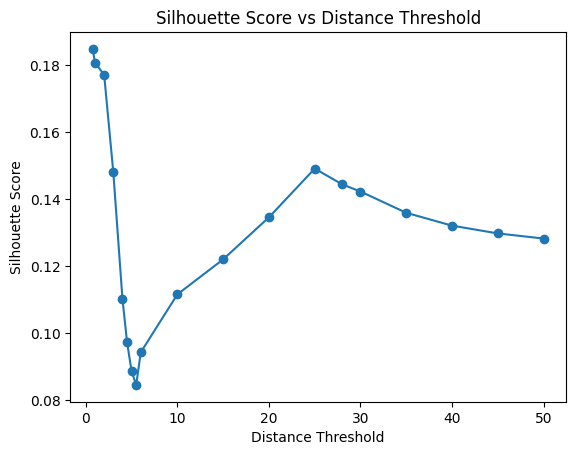

In [ ]:
#cluster embeddings using agglomerative clustering
from sklearn.cluster import AgglomerativeClustering
#try different thresholds for clustering and see how many clusters are formed, get silhouette score
from sklearn.metrics import silhouette_score    
thresholds = [.75, 1, 2.0, 3.0,  4.0, 4.5, 5.0, 5.5, 6.0, 10, 15, 20, 25,28,30, 35,40,45,50]
silhouette_scores = pd.DataFrame()
for thresh in thresholds:
    clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=thresh)
    cluster_labels = clustering.fit_predict(embeddings_subset)
    n_clusters = len(set(cluster_labels))
    if n_clusters > 1 and n_clusters < len(embeddings_subset):
        sil_score = silhouette_score(embeddings_subset, cluster_labels)
        sil_score_dict = {'threshold': thresh, 'n_clusters': n_clusters, 'silhouette_score': sil_score}
        sil_score_df = pd.DataFrame([sil_score_dict])
        silhouette_scores = pd.concat([silhouette_scores, sil_score_df], ignore_index=True)

    else:
        sil_score = None
    print(f"Threshold: {thresh}, Number of clusters: {n_clusters}, Silhouette Score: {sil_score}")
#plot silhouette scores
import matplotlib.pyplot as plt
plt.plot(silhouette_scores['threshold'], silhouette_scores['silhouette_score'], marker='o')
plt.xlabel('Distance Threshold')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Distance Threshold')
plt.show()
# write to csv
silhouette_scores.to_csv('../data/silhouette_scores.csv', index=False)
#get the best threshold based on silhouette score
best_thresh = silhouette_scores.loc[silhouette_scores['silhouette_score'].idxmax(), 'threshold']
print(f"Best Threshold: {best_thresh}")



Cluster subset based on best threshold and then assign all other points to a cluster        

In [ ]:
#cluster subset based on best threshold and then assign all other points to a cluster
clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=best_thresh)
cluster_labels = clustering.fit_predict(embeddings_subset)
#for all embeedings not in subset assign cluster labels based on nearest neighbor in subset
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=1)
nn.fit(embeddings_subset)
distances, indices = nn.kneighbors(embeddings)
#assign cluster labels from subset to all embeddings
embeddings_df['agglomerative_cluster'] = cluster_labels[indices.flatten()]
embeddings_df.head(2)

In [ ]:
#for all embeedings not in subset assign cluster labels based on nearest neighbor in subset
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=1)
nn.fit(embeddings_subset)
distances, indices = nn.kneighbors(embeddings)
#assign cluster labels from subset to all embeddings
embeddings_df['agglomerative_cluster'] = cluster_labels[indices.flatten()]



In [ ]:
#!pip3 install bertopic[openai] openai

#import openai
from bertopic.representation import OpenAI
from bertopic import BERTopic

# Create your representation model
client = openai.OpenAI(api_key="")
representation_model = OpenAI(client)

# Use the representation model in BERTopic on top of the default pipeline
topic_model = BERTopic(representation_model=representation_model)

# prompt = "I have the following documents: [DOCUMENTS] \nThese documents are about the following topic: '"
# # representation_model = OpenAI(client, prompt=prompt)
# # representation_model = OpenAI(client, model="gpt-4o-mini", delay_in_seconds=10)
# # prompt = """
# # I have a topic that contains the following documents:
# # [DOCUMENTS]
# # The topic is described by the following keywords: [KEYWORDS]

# # Based on the information above, extract a short topic label in the following format:
# # topic: <topic label>
# # """

ModuleNotFoundError: No module named 'bertopic'

In [ ]:
#use bertopic for topic modeling
from bertopic import BERTopic
topic_model = BERTopic()
topics, probs = topic_model.fit_transform(embeddings_subset)
hierarchical_topics = topic_model.hierarchical_topic_reduction(topics, nr_topics=10)
#view topics
topic_model.get_topic_info()
topic_model.get_topic(0)
#visualize topics
topic_model.visualize_topics()

from bertopic.representation import TextGeneration
from bertopic import BERTopic

# Create your representation model
representation_model = TextGeneration('DeepSeek-V3.2-Exp')

# Use the representation model in BERTopic on top of the default pipeline
topic_model = BERTopic(representation_model=representation_model)


In [35]:
#run clustering by company
company_clusters = pd.DataFrame()
for company in w_narr['company'].unique():
    print(f"Clustering for company: {company}")
    company_embeddings = embeddings_df.loc[embeddings_df.company == company, :].drop(columns=['complaint_id', 'date_received', 'company', 'product', 'consumer_complaint_narrative']).values
    if len(company_embeddings) < 2:
        print(f"Not enough data for company: {company}")
        continue
    for thresh in [5,5.5 , 6, 7,]:
        clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=thresh)
        cluster_labels = clustering.fit_predict(company_embeddings)
        #get the most common words in each cluster
        for i in range(n_clusters):
            cluster_indices = np.where(cluster_labels == i)[0]
            cluster_narratives = embeddings_df.loc[(embeddings_df.company == company) & (embeddings_df.index.isin(cluster_indices)), 'consumer_complaint_narrative'].values
            #get the most common words
            all_words = ' '.join(cluster_narratives).split()
            #remove common stop words
            from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
            all_words = [word.lower() for word in all_words if word.lower() not in ENGLISH_STOP_WORDS]
            from collections import Counter
            word_counts = Counter(all_words)
            common_words = word_counts.most_common(5)
            #print(f"Cluster {i} common words: {common_words}")
            # add threshold, cluster number, and common words embedding_df
            embeddings_df.loc[(embeddings_df.company == company) & (embeddings_df.index.isin(cluster_indices)), f'cluster_{thresh}_common_words'] = ', '.join([word for word, count in common_words])
            
        n_clusters = len(set(cluster_labels))
        #silhouette score
        if n_clusters > 1 and n_clusters < len(company_embeddings):
            sil_score = silhouette_score(company_embeddings, cluster_labels)
        else:
            sil_score = None
        print(f"Company: {company}, Threshold: {thresh}, Number of clusters: {n_clusters}, Silhouette Score: {sil_score}")
        cluster_dict = {'company': company, 'threshold': thresh, 'n_clusters': n_clusters, 'silhouette_score': sil_score}
        cluster_df = pd.DataFrame([cluster_dict])
        company_clusters = pd.concat([company_clusters, cluster_df], ignore_index=True)

Clustering for company: WELLS FARGO & COMPANY
Company: WELLS FARGO & COMPANY, Threshold: 5, Number of clusters: 1135, Silhouette Score: 0.01150439865887165


KeyboardInterrupt: 